In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Prepare the Matrix
# Pivot: Rows = Models, Cols = Tags
df = pd.read_csv("clirener_aggregated_mean_std.csv")

matrix = df.pivot(index='model_display_name', columns='tag', values='strict_f1_mean').fillna(0)

# Optional: Drop rows that are completely empty/broken if desired, 
# but keeping them shows they are outliers (like SciClimateBERT in your data)

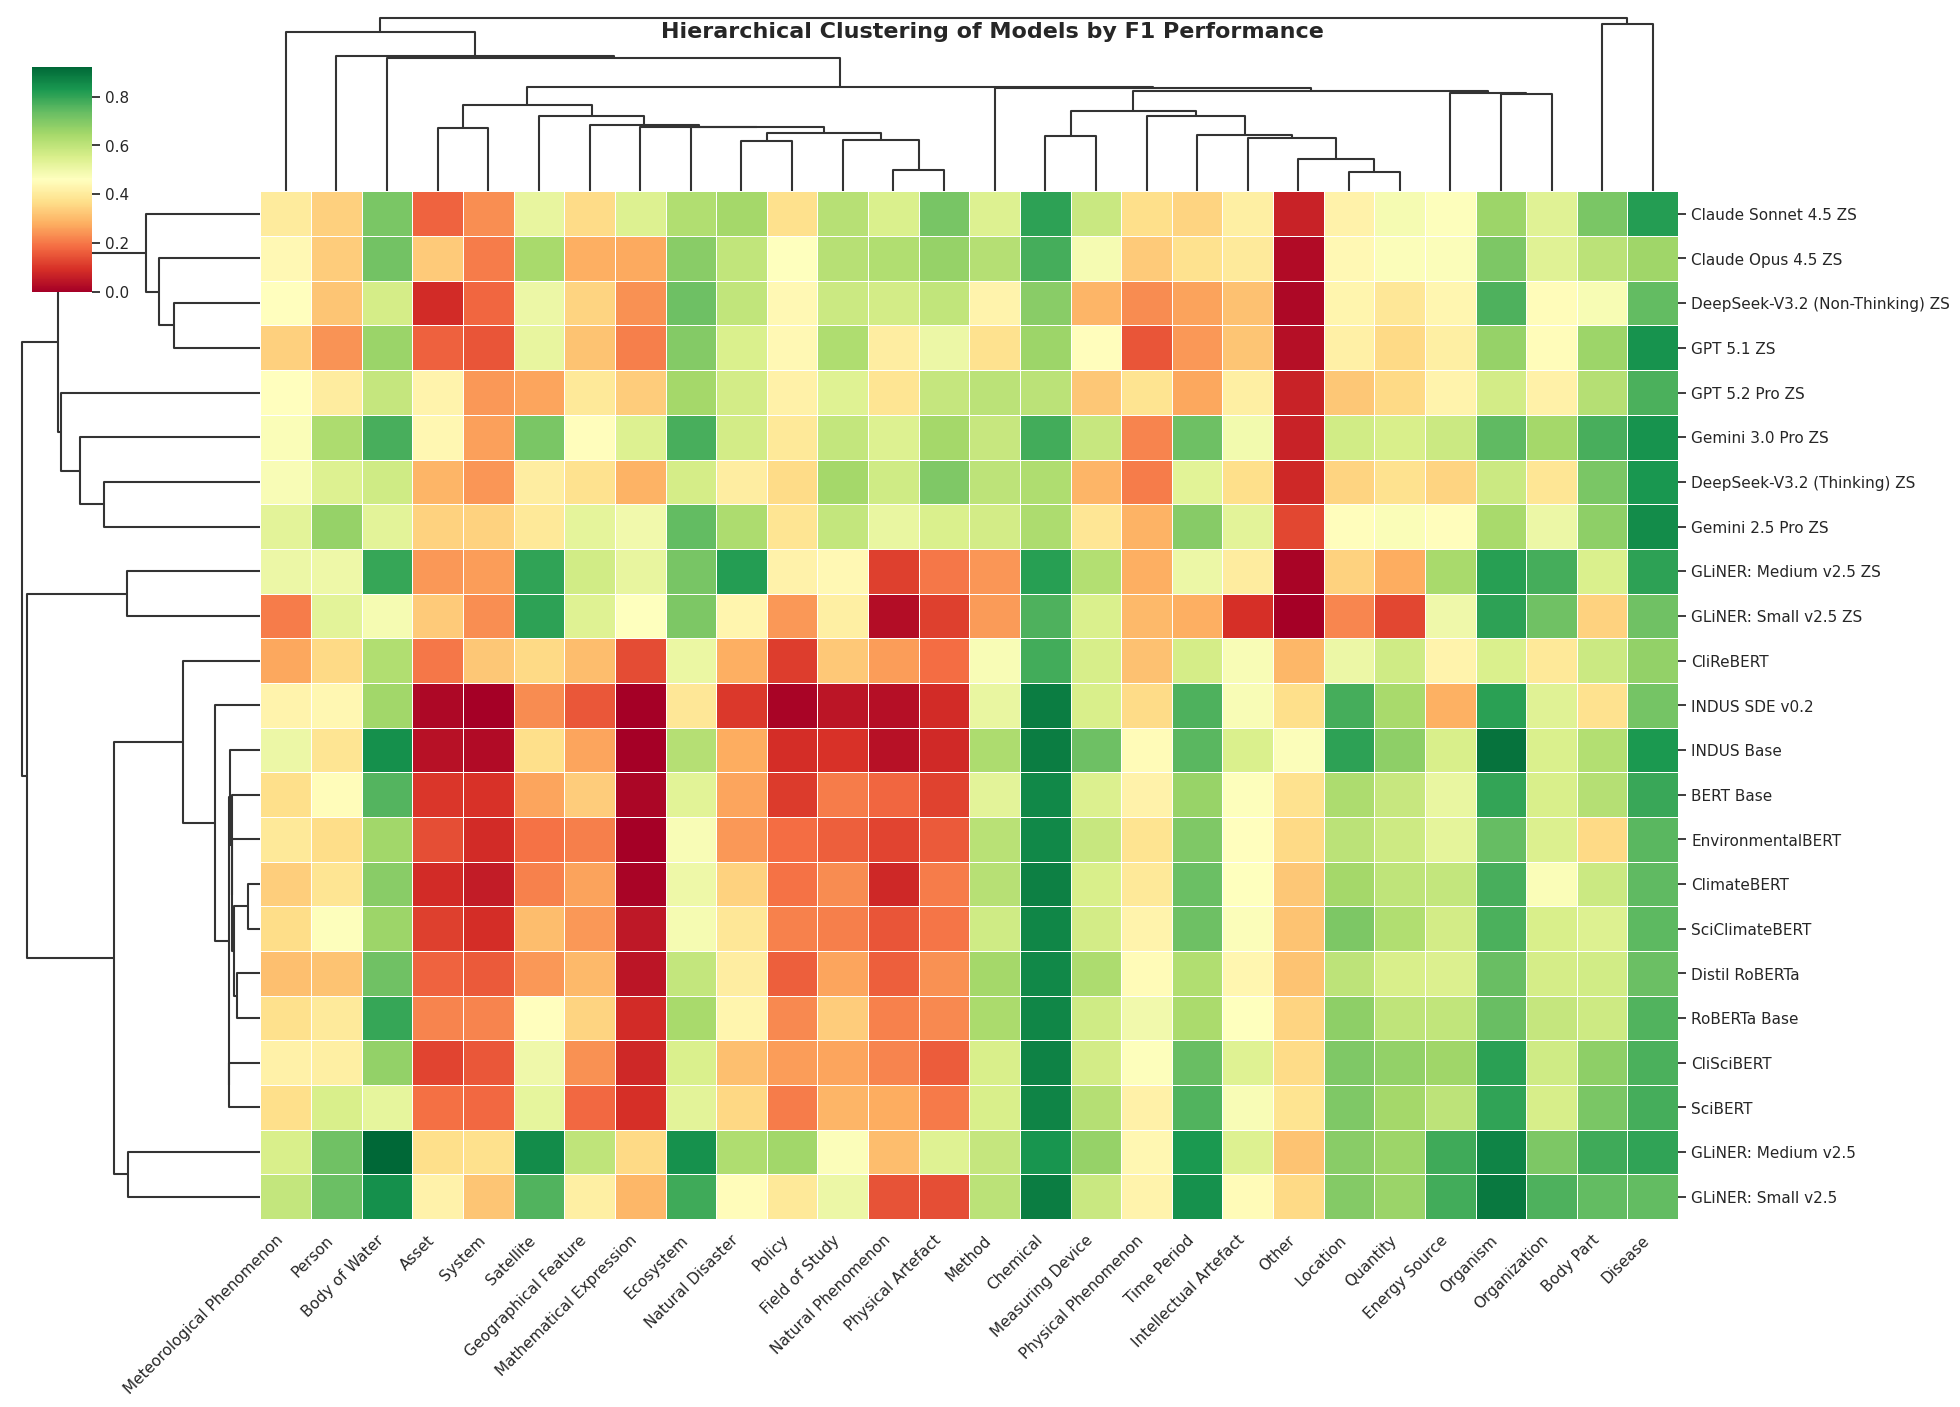

Cluster-Sorted Model List (Copy this to Vega-Lite 'sort'):
['Claude Sonnet 4.5 ZS', 'Claude Opus 4.5 ZS', 'DeepSeek-V3.2 (Non-Thinking) ZS', 'GPT 5.1 ZS', 'GPT 5.2 Pro ZS', 'Gemini 3.0 Pro ZS', 'DeepSeek-V3.2 (Thinking) ZS', 'Gemini 2.5 Pro ZS', 'GLiNER: Medium v2.5 ZS', 'GLiNER: Small v2.5 ZS', 'CliReBERT', 'INDUS SDE v0.2', 'INDUS Base', 'BERT Base', 'EnvironmentalBERT', 'ClimateBERT', 'SciClimateBERT', 'Distil RoBERTa', 'RoBERTa Base', 'CliSciBERT', 'SciBERT', 'GLiNER: Medium v2.5', 'GLiNER: Small v2.5']


In [2]:
# Set general aesthetic
sns.set_theme(style="white")

# Create the clustermap
g = sns.clustermap(
    matrix,
    method='single',           # Ward's method minimizes variance within clusters
    metric='correlation',
    cmap="RdYlGn",           # Yellow-Green-Blue is colorblind friendly and clean
    figsize=(20, 15),        # Large size for readability
    dendrogram_ratio=(0.15, 0.15), # Control size of the tree diagram
    cbar_pos=(0.02, 0.8, 0.03, 0.15), # Move colorbar to top left (x, y, w, h)
    linewidths=0.5,          # Grid lines
    linecolor='white',
    tree_kws=dict(linewidths=1.5)
)

# Adjust axes
g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right", fontsize=11)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=11)

# Add Title (moved slightly to not overlap dendrogram)
g.fig.suptitle('Hierarchical Clustering of Models by F1 Performance', y=0.98, fontsize=16, fontweight='bold')

plt.show()

# --- EXTRACT THE SORTED ORDER ---
# This is the magic list you need for your Vega-Lite Y-axis sort
reordered_indices = g.dendrogram_row.reordered_ind
sorted_models = matrix.index[reordered_indices].tolist()
print("Cluster-Sorted Model List (Copy this to Vega-Lite 'sort'):")
print(sorted_models)

In [4]:
# 1. Calculate PCA (2D projection)
pca = PCA(n_components=2)
components = pca.fit_transform(matrix)

# 2. Calculate Clusters (Auto-detect e.g., 4 groups)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmeans.fit_predict(matrix)

# 3. Create DataFrame for Plotting
plot_df = pd.DataFrame(data=components, columns=['PC1', 'PC2'], index=matrix.index)
plot_df['Cluster'] = clusters.astype(str)
plot_df['Model'] = plot_df.index
plot_df['Mean_F1'] = matrix.mean(axis=1) # Calculate overall mean for hover info

# 4. Plot
fig = px.scatter(
    plot_df, 
    x='PC1', 
    y='PC2', 
    color='Cluster',
    symbol='Cluster',
    hover_name='Model',
    hover_data={'Mean_F1': ':.3f', 'PC1': False, 'PC2': False, 'Cluster': False},
    title='Model Similarity Map (PCA)',
    template='plotly_white',
    width=1000,
    height=700,
    size_max=15
)

fig.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(
    legend_title_text='Detected Group',
    xaxis_title="Principal Component 1 (Overall Performance)",
    yaxis_title="Principal Component 2 (Specialization Pattern)"
)

fig.show()

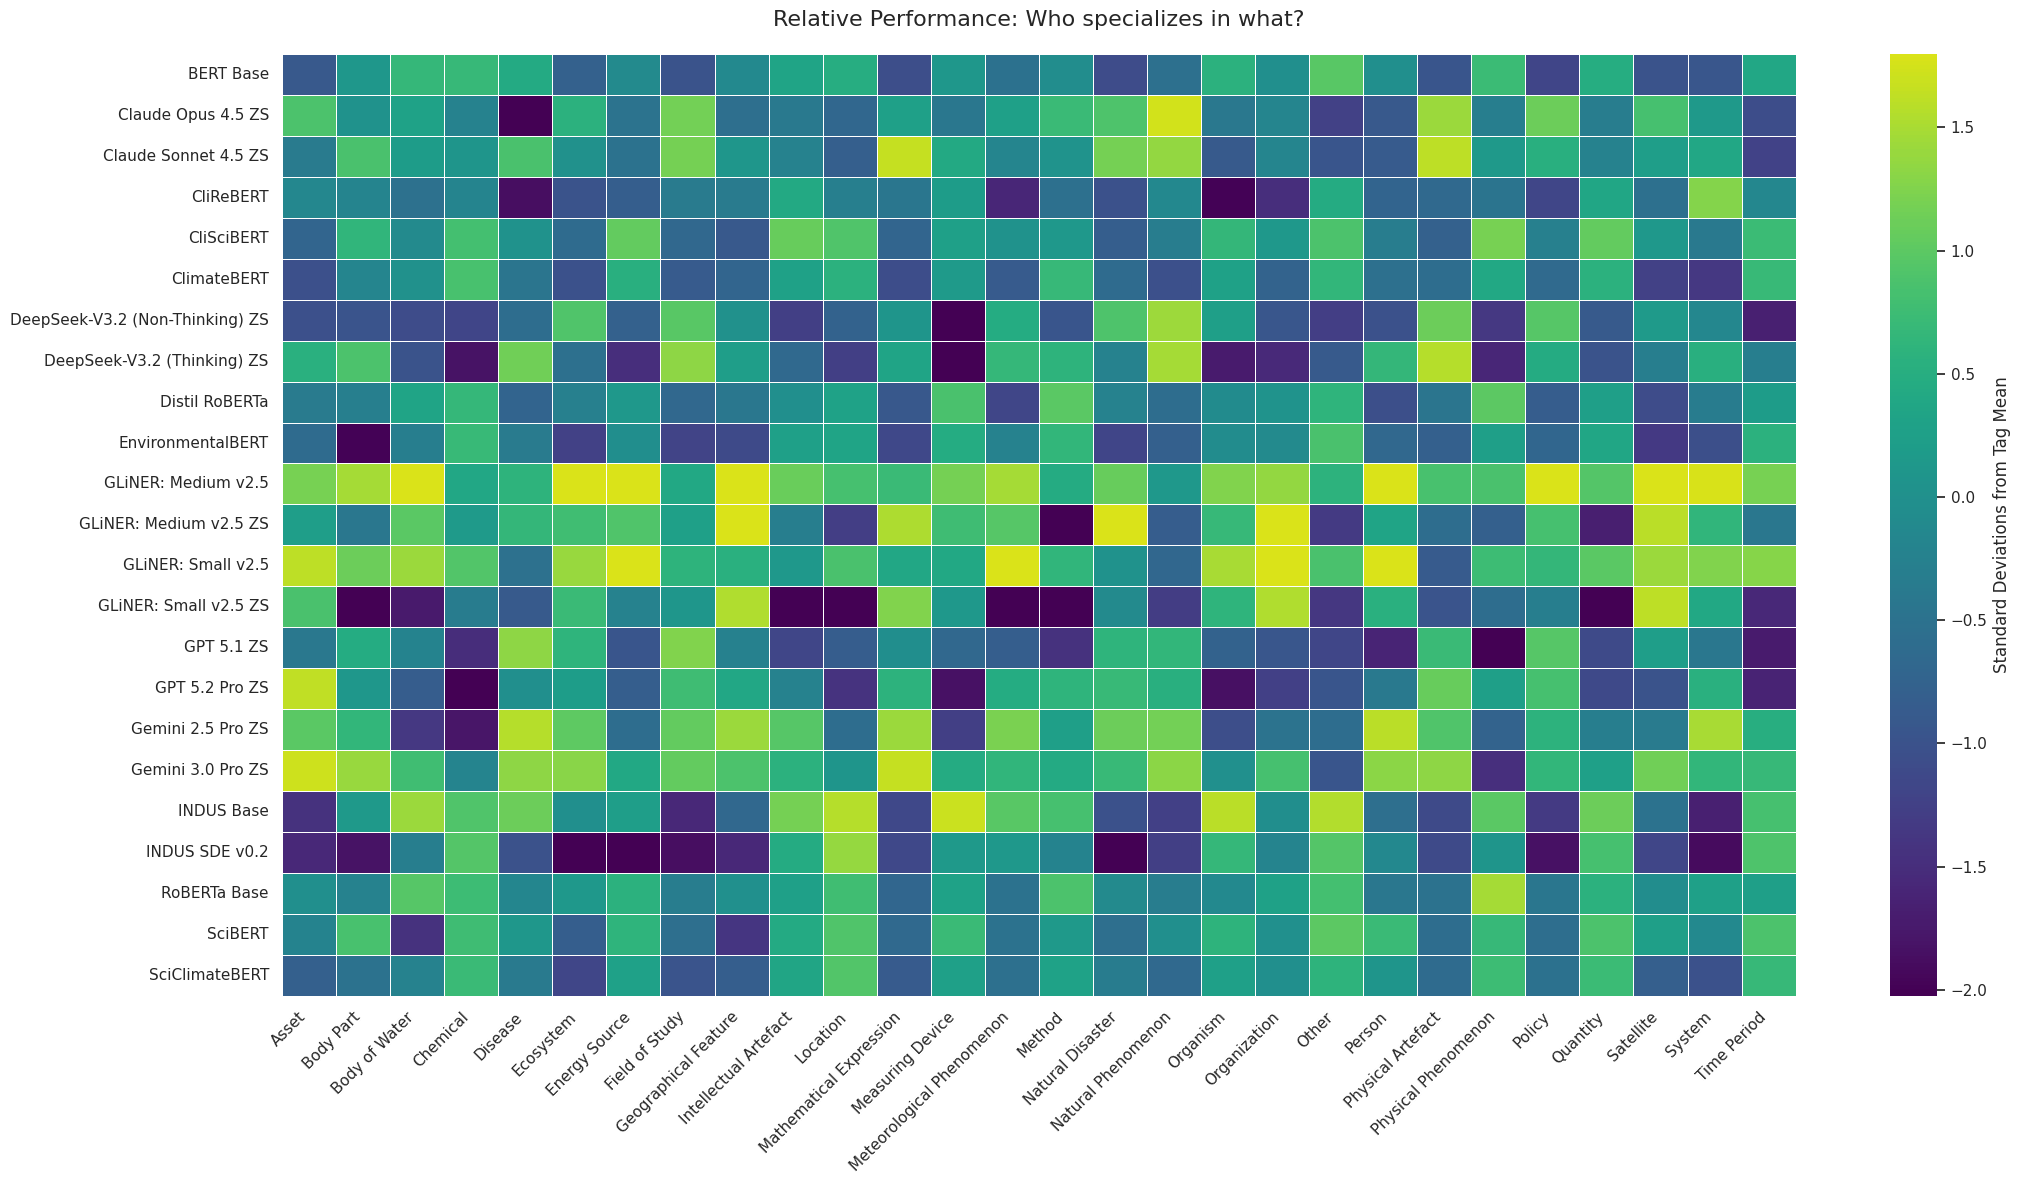

In [5]:
# Calculate Z-score (standardized deviation from the mean of that tag)
# (Value - Mean) / StdDev
z_matrix = (matrix - matrix.mean()) / matrix.std()

plt.figure(figsize=(22, 12))
sns.heatmap(
    z_matrix, 
    cmap="viridis", # Red-White-Blue diverging palette (Reversed so Blue is high)
    center=0,      # White = Average performance
    robust=True,   # Ignore extreme outliers in color scaling
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Standard Deviations from Tag Mean'}
)

plt.title("Relative Performance: Who specializes in what?", fontsize=16, pad=20)
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

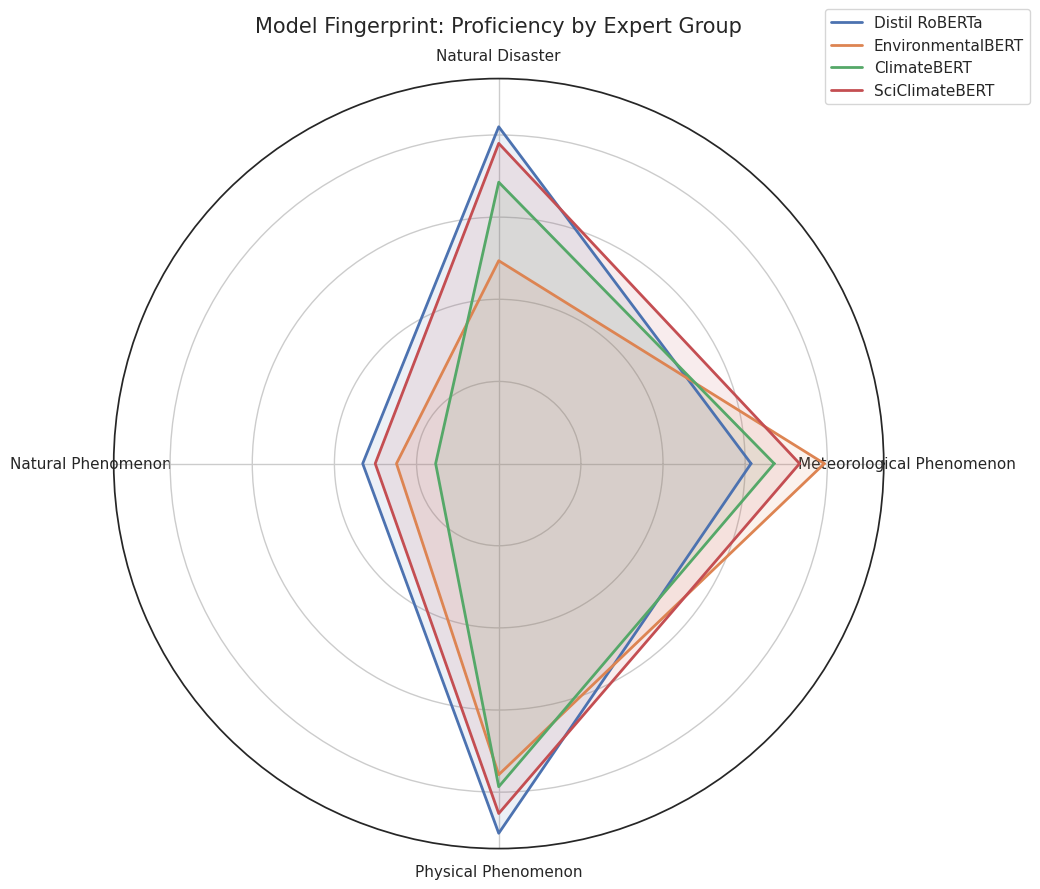

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define your groups
groups = {
    "G1: Policy": ["Asset", "Policy"],
    "G2: Science": ["Method", "Field of Study", "Intellectual Artefact"],
    "G3: Geographical": ["Location", "Geographical Feature", "Body of Water", "Time Period"],
    
    "G4: Physics": ["Satellite", "Mathematical Expression", "Measuring Device", "Physical Phenomenon", "Quantity"],
    # "G3: Physics/Math": [],
    "G5: Biology/Environment": ["Body Part", "Organism", "Ecosystem"],
    "G6: Med/Chem": ["Chemical", "Disease", "Energy Source"],
    "G7: Meteorology": ["Meteorological Phenomenon",],
    "G5: Natural Events": ["Natural Disaster", "Natural Phenomenon"],
    "G6: Artifacts/Orgs": ["Physical Artefact", "Organization", "Person", "System"]
}



# Assuming you have a list of your tags
all_tags = [
    # "Asset", "Policy", 
    "Method", 
    # "Field of Study", "Intellectual Artefact",
    "Location", 
    # "Geographical Feature", "Body of Water", "Time Period",
    # "Satellite", "Mathematical Expression", 
    "Measuring Device", 
    # "Physical Phenomenon", 
    "Quantity", 
    # "Body Part", 
    "Organism", 
    # "Ecosystem", 
    "Chemical", 
    # "Disease", "Energy Source", 
    "Meteorological Phenomenon", 
    # "Natural Disaster", "Natural Phenomenon", 
    # "Physical Artefact", 
    "Organization", 
    # "Person", "System"
]

all_tags = [
    # "Asset", 
    "Policy", 
    # "Method", 
    "Field of Study", # "Intellectual Artefact",
    # "Location", 
    # "Geographical Feature", "Body of Water", 
    "Time Period",
    "Satellite", # "Mathematical Expression", 
    "Measuring Device", 
    # # "Physical Phenomenon", 
    # "Quantity", 
    "Body Part", 
    # "Organism", 
    # # "Ecosystem", 
    # "Chemical", 
    "Disease", 
    "Energy Source", 
    "Meteorological Phenomenon", 
    # # "Natural Disaster", 
    "Natural Phenomenon", 
    # # "Physical Artefact", 
    "Organization", 
    "Person", 
    "System"
]

all_tags = [
    "Asset", "Policy", "Method", "Field of Study", "Intellectual Artefact",
    "Location", "Geographical Feature", "Body of Water", "Time Period","Satellite", 
    "Mathematical Expression", "Measuring Device", "Physical Phenomenon", "Quantity", 
    "Body Part", "Organism", "Ecosystem", "Chemical", "Disease", 
    "Energy Source", "Meteorological Phenomenon",  "Natural Disaster", "Natural Phenomenon", 
    "Physical Artefact", "Organization", "Person", "System"
]

all_tags = [
    # "Asset", "Policy", "Method", "Field of Study", "Intellectual Artefact",
    # "Location", "Geographical Feature", "Body of Water", "Time Period","Satellite", 
    # "Mathematical Expression", "Measuring Device", 
    "Physical Phenomenon", 
    # "Quantity", 
    # "Body Part", "Organism", "Ecosystem", "Chemical", "Disease", 
    # "Energy Source", 
    "Meteorological Phenomenon",  "Natural Disaster", "Natural Phenomenon", 
    # "Physical Artefact", "Organization", "Person", "System"
]

# Create the dictionary dynamically
groups = {tag: [tag] for tag in all_tags}

# groups = {
#     # Proper Nouns / Standard NER types (Usually Easiest)
#     "Named Entities": [
#         "Person", "Organization", "Location", "Satellite", "Body of Water"
#     ],
    
#     # Concrete Technical Terms (Medium Difficulty)
#     "Scientific Terms": [
#         "Chemical", "Disease", "Organism", "Body Part", 
#         "Measuring Device", "Physical Artefact"
#     ],
    
#     # Measurements and Numbers
#     "Quantitative": [
#         "Quantity", "Mathematical Expression", "Time Period", "Energy Source"
#     ],
    
#     # Abstract Concepts (Usually Hardest - require understanding context)
#     "Abstract Concepts": [
#         "Method", "System", "Policy", "Asset", "Field of Study", 
#         "Intellectual Artefact", "Objective" # Added Objective if present
#     ],
    
#     # Environmental Events (Descriptive)
#     "Events & Phenomena": [
#         "Natural Disaster", "Natural Phenomenon", "Meteorological Phenomenon",
#         "Physical Phenomenon", "Geographical Feature", "Ecosystem"
#     ]
# }

# 2. Map tags to groups in the dataframe
tag_to_group = {tag: group for group, tags in groups.items() for tag in tags}
df['expert_group'] = df['tag'].map(tag_to_group)

# 3. Select 3 distinct models to compare (Avoid cluttering)
selected_models = [
    # "RoBERTa Base", 
    # "INDUS Base", "INDUS SDE v0.2",
    
    # "BERT Base", "SciBERT", "CliSciBERT", "CliReBERT",

    "Distil RoBERTa", "EnvironmentalBERT", "ClimateBERT",
    "SciClimateBERT",

    # "GLiNER: Small v2.5 ZS",
    # "GLiNER: Small v2.5",
    # "GLiNER: Medium v2.5 ZS",
    # "GLiNER: Medium v2.5",

    # "GPT 5.1 ZS",
    # "GPT 5.2 Pro ZS",
    # "DeepSeek-V3.2 (Non-Thinking) ZS",
    # "DeepSeek-V3.2 (Thinking) ZS",
    # "Claude Opus 4.5 ZS",
    # "Claude Sonnet 4.5 ZS",
    # "Gemini 3.0 Pro ZS",
    # "Gemini 2.5 Pro ZS"
]


subset = df[df['model_display_name'].isin(selected_models)]

# 4. Aggregate F1 by Model and Group
radar_data = subset.groupby(['model_display_name', 'expert_group'])['strict_f1_mean'].mean().unstack().fillna(0)

# 5. Build Radar Chart
labels = list(radar_data.columns)
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Close the loop

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for model in selected_models:
    values = radar_data.loc[model].tolist()
    values += values[:1] # Close the loop
    ax.plot(angles, values, linewidth=2, label=model)
    ax.fill(angles, values, alpha=0.1)

ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
plt.title("Model Fingerprint: Proficiency by Expert Group", y=1.05, fontsize=15)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()

In [33]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, pipeline
import torch

# Load the pretrained model and tokenizer
model_name = "P0L3/sciclimatebert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForMaskedLM.from_pretrained(model_name)

# Move model to GPU if available
device = 0 if torch.cuda.is_available() else -1

# Create a fill-mask pipeline
fill_mask = pipeline("fill-mask", model=model, tokenizer=tokenizer, device=device)

# Example input from scientific climate literature
text = "The increase in greenhouse gas emissions has significantly affected the <mask> balance of the Earth."

# Run prediction
predictions = fill_mask(text)

# Show top predictions
print(text)
print(10*">")
for p in predictions:
    print(f"{p['sequence']} — {p['score']:.4f}")


Device set to use cuda:0


The increase in greenhouse gas emissions has significantly affected the <mask> balance of the Earth.
>>>>>>>>>>
The increase in greenhouse gas emissions has significantly affected the energy balance of the Earth. — 0.7897
The increase in greenhouse gas emissions has significantly affected the radiation balance of the Earth. — 0.0522
The increase in greenhouse gas emissions has significantly affected the mass balance of the Earth. — 0.0401
The increase in greenhouse gas emissions has significantly affected the water balance of the Earth. — 0.0359
The increase in greenhouse gas emissions has significantly affected the carbon balance of the Earth. — 0.0190


## Model qualitative comparison

In [2]:
!pip3 install wandb

^C


c:\Users\Desktop\miniforge3\envs\clirener_finetune\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'dataset_processing'

In [27]:
text = "We release our datasets, guidelines, and fine-tuned models to support advanced knowledge extraction in the climate change research [MASK]"# climate change research."

In [28]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, pipeline
import torch

# Load the pretrained model and tokenizer
model_name = "P0L3/clirebert_clirevocab_uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForMaskedLM.from_pretrained(model_name)

# Move model to GPU if available
device = 0 if torch.cuda.is_available() else -1

# Create a fill-mask pipeline
fill_mask = pipeline("fill-mask", model=model, tokenizer=tokenizer, device=device)

# Example input from scientific climate literature
# text = "The rapid growth of scientific literature on anthropogenic climate change necessitates automated information extraction to manage and synthesise complex, multi-scalar climate [MASK]."

# Run prediction
predictions = fill_mask(text)

# Show top predictions
print(model_name)
print(text)
print(10*">")
for p in predictions:
    print(f"{p['sequence']} — {p['score']:.4f}")


Device set to use cuda:0


P0L3/clirebert_clirevocab_uncased
We release our datasets, guidelines, and fine-tuned models to support advanced knowledge extraction in the climate change research [MASK]
>>>>>>>>>>
we release our datasets , guidelines , and fine - tuned models to support advanced knowledge extraction in the climate change research . — 0.9160
we release our datasets , guidelines , and fine - tuned models to support advanced knowledge extraction in the climate change research community — 0.0114
we release our datasets , guidelines , and fine - tuned models to support advanced knowledge extraction in the climate change research references — 0.0112
we release our datasets , guidelines , and fine - tuned models to support advanced knowledge extraction in the climate change research institute — 0.0063
we release our datasets , guidelines , and fine - tuned models to support advanced knowledge extraction in the climate change research acknowledgments — 0.0028


In [29]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, pipeline
import torch

# Load the pretrained model and tokenizer
model_name = "P0L3/cliscibert_scivocab_uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForMaskedLM.from_pretrained(model_name)

# Move model to GPU if available
device = 0 if torch.cuda.is_available() else -1

# Create a fill-mask pipeline
fill_mask = pipeline("fill-mask", model=model, tokenizer=tokenizer, device=device)

# Example input from scientific climate literature
# text = "The rapid growth of scientific literature on anthropogenic climate change necessitates automated information extraction to manage and synthesise complex, multi-scalar climate [MASK]."

# Run prediction
predictions = fill_mask(text)

# Show top predictions
print(model_name)
print(text)
print(10*">")
for p in predictions:
    print(f"{p['sequence']} — {p['score']:.4f}")


Device set to use cuda:0


P0L3/cliscibert_scivocab_uncased
We release our datasets, guidelines, and fine-tuned models to support advanced knowledge extraction in the climate change research [MASK]
>>>>>>>>>>
we release our datasets, guidelines, and fine - tuned models to support advanced knowledge extraction in the climate change research. — 0.9999
we release our datasets, guidelines, and fine - tuned models to support advanced knowledge extraction in the climate change research? — 0.0000
we release our datasets, guidelines, and fine - tuned models to support advanced knowledge extraction in the climate change research, — 0.0000
we release our datasets, guidelines, and fine - tuned models to support advanced knowledge extraction in the climate change research — — 0.0000
we release our datasets, guidelines, and fine - tuned models to support advanced knowledge extraction in the climate change research ’ — 0.0000


In [30]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, pipeline
import torch

# Load the pretrained model and tokenizer
model_name = "P0L3/sciclimatebert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForMaskedLM.from_pretrained(model_name)

# Move model to GPU if available
device = 0 if torch.cuda.is_available() else -1

# Create a fill-mask pipeline
fill_mask = pipeline("fill-mask", model=model, tokenizer=tokenizer, device=device)

# Example input from scientific climate literature
# text = "The rapid growth of scientific literature on anthropogenic climate change necessitates automated information extraction to manage and synthesise complex, multi-scalar climate <mask>."

# Run prediction
predictions = fill_mask(text.replace("[MASK]", "<mask>"))

# Show top predictions
print(model_name)
print(text)
print(10*">")
for p in predictions:
    print(f"{p['sequence']} — {p['score']:.4f}")


Device set to use cuda:0


P0L3/sciclimatebert
We release our datasets, guidelines, and fine-tuned models to support advanced knowledge extraction in the climate change research [MASK]
>>>>>>>>>>
We release our datasets, guidelines, and fine-tuned models to support advanced knowledge extraction in the climate change research. — 0.9990
We release our datasets, guidelines, and fine-tuned models to support advanced knowledge extraction in the climate change research . — 0.0004
We release our datasets, guidelines, and fine-tuned models to support advanced knowledge extraction in the climate change research: — 0.0001
We release our datasets, guidelines, and fine-tuned models to support advanced knowledge extraction in the climate change research? — 0.0001
We release our datasets, guidelines, and fine-tuned models to support advanced knowledge extraction in the climate change research! — 0.0001


In [12]:
text = "The urgency of understanding complex, multi-scalar [MASK] [MASK] has led to rapid growth in research output."
text = "Named entity recognition has also gained [MASK] [MASK], resulting in datasets such as BiodivNER (Abdelmageed et al. 2022), Climate-Change NER (Bhattacharjee et al. 2024), and ClimateIE (Pan et al. 2025)."
text = "[MASK] [MASK] [MASK], we define a total of 28 NER types (27 domain-specific types plus Other)."
text = "We note that the final count for each entity type depends on annotator agreement and may therefore fall below this threshold; nevertheless, this procedure yields a [MASK] [MASK] distribution with approximately 50 examples per entity type."
text = "Given these differences, the results in Figure 6 are [MASK] [MASK] expected."

model_name = "P0L3/clirebert_clirevocab_uncased"
# model_name = "P0L3/cliscibert_scivocab_uncased"
# model_name = "P0L3/sciclimatebert"
if model_name == "P0L3/sciclimatebert":
    text = text.replace("[MASK]", "<mask>")

In [13]:
import torch
from transformers import AutoModelForMaskedLM, AutoTokenizer
import torch.nn.functional as F

def beam_search_bert(model_name, input_text, beam_width=5, num_return_sequences=3):
    # 1. Load Model and Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForMaskedLM.from_pretrained(model_name)
    model.eval()
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    mask_token_id = tokenizer.mask_token_id

    # 2. Prepare initial input
    # We maintain a list of tuples: (input_ids_tensor, current_score)
    input_ids = tokenizer.encode(input_text, return_tensors="pt").to(device)
    
    # Check if there are masks to fill
    if mask_token_id not in input_ids:
        print("No masks found in input.")
        return [input_text]

    # Initialize beams: List of [sequence, cumulative_log_prob]
    beams = [(input_ids, 0.0)]

    # 3. Iterative Beam Search Loop
    # We loop as long as there are masks in the best candidate
    while True:
        candidates = []
        masks_remaining = False

        for seq, score in beams:
            # Find all mask positions in this specific sequence
            mask_indices = (seq == mask_token_id).nonzero(as_tuple=True)[1]
            
            # If no masks left in this beam, add it to candidates as is and continue
            if len(mask_indices) == 0:
                candidates.append((seq, score))
                continue
            
            masks_remaining = True
            
            # Target the FIRST mask found (Iterative approach ensures dependency)
            target_mask_index = mask_indices[0]

            with torch.no_grad():
                outputs = model(seq)
                logits = outputs.logits # [1, seq_len, vocab_size]
            
            # Get probabilities for the target mask position
            target_logits = logits[0, target_mask_index, :]
            log_probs = F.log_softmax(target_logits, dim=-1)

            # Get top-k tokens for this specific mask
            top_log_probs, top_indices = torch.topk(log_probs, beam_width)

            # Create new beams
            for i in range(beam_width):
                token_id = top_indices[i].unsqueeze(0)
                token_score = top_log_probs[i].item()

                # Create new sequence with the mask filled
                new_seq = seq.clone()
                new_seq[0, target_mask_index] = token_id
                
                # Update score (sum of log probabilities)
                new_score = score + token_score
                
                candidates.append((new_seq, new_score))

        # Sort candidates by score (highest log prob first) and keep top beams
        candidates = sorted(candidates, key=lambda x: x[1], reverse=True)
        beams = candidates[:beam_width]

        # If no beams had masks remaining, we are done
        if not masks_remaining:
            break

    # 4. Decode and return results
    results = []
    for seq, score in beams[:num_return_sequences]:
        decoded_text = tokenizer.decode(seq[0], skip_special_tokens=True)
        results.append((decoded_text, score))
        
    del model  #deleting the model 


    # model will still be on cache until its place is taken by other objects so also execute the below lines
    import gc         # garbage collect library
    gc.collect()
    torch.cuda.empty_cache() 

    return results

# --- Usage Example ---

# A sentence where the two masks are highly dependent.
# If the first is "San", the second should be "Francisco".
# If the first is "New", the second should be "York".

print(model_name)
top_sequences = beam_search_bert(
    model_name=model_name,
    input_text=text,
    beam_width=10,        # Equivalent to "Top 10"
    num_return_sequences=5
)

print(f"Input: {text}\n")
for i, (txt, score) in enumerate(top_sequences):
    print(f"Rank {i+1} (Score: {score:.2f}): {txt}")

P0L3/clirebert_clirevocab_uncased
Input: Given these differences, the results in Figure 6 are [MASK] [MASK] expected.

Rank 1 (Score: -2.52): given these differences , the results in figure 6 are to be expected .
Rank 2 (Score: -2.84): given these differences , the results in figure 6 are not as expected .
Rank 3 (Score: -3.33): given these differences , the results in figure 6 are , as expected .
Rank 4 (Score: -3.52): given these differences , the results in figure 6 are similar as expected .
Rank 5 (Score: -3.64): given these differences , the results in figure 6 are reasonable as expected .
